In [1]:
#========================================================================
# Name: plot_goes_csapr_stats.ipynb
# Author: McKenna W. Stanford
# Author Contact: mckenna.stanford@pnnl.gov
# Date Created: 01/13/2025
#
# Utility: Plots GOES CTT/IR Tb and CSAPR statistics
#========================================================================

In [16]:
#===============================
# Imports
#===============================
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import glob
from matplotlib.collections import PatchCollection
from matplotlib.patches import Rectangle, Patch
from matplotlib.lines import Line2D
import matplotlib.gridspec as gridspec
import datetime
import matplotlib.colors as colors
import matplotlib as mpl
from pytz import utc
from matplotlib.lines import Line2D


import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import cartopy.io.img_tiles as cimgt
import shapely.geometry as sgeom
import matplotlib.patheffects as path_effects
import pandas as pd
import time
import warnings
import scipy
warnings.filterwarnings("ignore")
import os

## Functions

In [2]:
def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return array[idx], idx

def to_datetime(date):
    """
    Converts a numpy datetime64 object to a python datetime object 
    Input:
      date - a np.datetime64 object
    Output:
      DATE - a python datetime object
    """
    timestamp = ((date - np.datetime64('1970-01-01T00:00:00'))
                 / np.timedelta64(1, 's'))
    
    return datetime.datetime.fromtimestamp(timestamp, datetime.UTC)

In [3]:
if False:
    csapr_path = '/global/cfs/projectdirs/m1657/avarble/cacti/3km/csapr/'
    csapr_files = sorted(glob.glob(csapr_path+'*.nc'))
    num_csapr_files = len(csapr_files)
    print('# of CSAPR files:',num_csapr_files)

In [4]:
csapr_path = '/pscratch/sd/m/mckenna/cacti/csapr_coarse_grained_regridded/3km/'
#csapr_path = '/global/cfs/projectdirs/m1657/avarble/cacti/Taranis/taranis_corcsapr2cfrppiqcM1_gridded.c1/'
csapr_files = sorted(glob.glob(csapr_path+'*.nc'))
num_csapr_files = len(csapr_files)
print('# of CSAPR files:',num_csapr_files)

# of CSAPR files: 8027


In [5]:
goes_path = '/global/cfs/projectdirs/m1657/avarble/cacti/3km/satellite_ir/'
goes_files = sorted(glob.glob(goes_path+'*.nc'))
num_goes_files = len(goes_files)
print('# of GOES files:',num_goes_files)

# of GOES files: 21765


## Construct list of datetimes and timestamps that correspond to CSAPR files

In [6]:
if False:
    csapr_datetime = []
    csapr_timestamp = []
    csapr_day = []
    
    for ii in range(num_csapr_files):
        tmp_str = csapr_files[ii].split('/')[-1]
        tmp_str = tmp_str.split('_')[-1]
        tmp_str = tmp_str.split('.')
        tmp_str = tmp_str[0]
        tmp_date = tmp_str[0:8]
        tmp_time = tmp_str[8:]
        tmp_year = int(tmp_date[0:4])
        tmp_month = int(tmp_date[4:6])
        tmp_day = int(tmp_date[6:8])
        tmp_hour = int(tmp_time[0:2])
        tmp_min = int(tmp_time[2:4])
        tmp_sec = int(tmp_time[4:6])
        tmp_datetime = datetime.datetime(tmp_year,tmp_month,tmp_day,tmp_hour,tmp_min,tmp_sec,tzinfo=utc)
        tmp_day = datetime.datetime(tmp_year,tmp_month,tmp_day,tzinfo=utc)
        tmp_timestamp = int(tmp_datetime.timestamp())
        csapr_datetime.append(tmp_datetime)
        csapr_timestamp.append(tmp_timestamp)
        csapr_day.append(tmp_day)
        
    csapr_timestamp = np.array(csapr_timestamp)
    csapr_datetime = np.array(csapr_datetime)
    csapr_day = np.array(csapr_day)
    unique_csapr_day = np.unique(csapr_day)

In [7]:
csapr_datetime = []
csapr_timestamp = []
csapr_day = []

for ii in range(num_csapr_files):
    tmp_str = csapr_files[ii].split('/')[-1]
    tmp_str = tmp_str.split('_')[-4]
    tmp_str = tmp_str.split('.')
    tmp_date = tmp_str[-2]
    tmp_time = tmp_str[-1]
    tmp_year = int(tmp_date[0:4])
    tmp_month = int(tmp_date[4:6])
    tmp_day = int(tmp_date[6:8])
    tmp_hour = int(tmp_time[0:2])
    tmp_min = int(tmp_time[2:4])
    tmp_sec = int(tmp_time[4:6])
    tmp_datetime = datetime.datetime(tmp_year,tmp_month,tmp_day,tmp_hour,tmp_min,tmp_sec,tzinfo=utc)
    tmp_day = datetime.datetime(tmp_year,tmp_month,tmp_day,tzinfo=utc)
    tmp_timestamp = int(tmp_datetime.timestamp())
    csapr_datetime.append(tmp_datetime)
    csapr_timestamp.append(tmp_timestamp)
    csapr_day.append(tmp_day)
    
csapr_timestamp = np.array(csapr_timestamp)
csapr_datetime = np.array(csapr_datetime)
csapr_day = np.array(csapr_day)
unique_csapr_day = np.unique(csapr_day)

## Construct list of datetimes and timestamps that correspond to GOES files

In [8]:
goes_datetime = []
goes_timestamp = []
goes_day = []
for ii in range(num_goes_files):
    tmp_str = goes_files[ii].split('/')[-1]
    tmp_str = tmp_str.split('_')[-1]
    tmp_str = tmp_str.split('.')
    tmp_date = tmp_str[-3]
    tmp_time = tmp_str[-2]
    tmp_year = int(tmp_date[0:4])
    tmp_month = int(tmp_date[4:6])
    tmp_day = int(tmp_date[6:8])
    tmp_hour = int(tmp_time[0:2])
    tmp_min = int(tmp_time[2:4])
    tmp_sec = int(tmp_time[4:6])
    tmp_datetime = datetime.datetime(tmp_year,tmp_month,tmp_day,tmp_hour,tmp_min,tmp_sec,tzinfo=utc)
    tmp_day = datetime.datetime(tmp_year,tmp_month,tmp_day,tzinfo=utc)
    tmp_timestamp = int(tmp_datetime.timestamp())
    goes_datetime.append(tmp_datetime)
    goes_timestamp.append(tmp_timestamp)
    goes_day.append(tmp_day)
    
goes_timestamp = np.array(goes_timestamp)
goes_datetime = np.array(goes_datetime)
goes_day = np.array(goes_day)
unique_goes_day = np.unique(goes_day)

# Loop through CSAPR times and find corresponding GOES time, if it exists

In [9]:
goes_match_files = []
goes_match_timestamp = []
goes_match_datetime = []
goes_match_day = []

csapr_match_files = []
csapr_match_timestamp = []
csapr_match_datetime = []
csapr_match_day = []

for ii in range(len(csapr_timestamp)):
    time_diff = np.abs(csapr_timestamp[ii]-goes_timestamp)
    min_time = np.min(time_diff)
    if min_time < 60.:
        dumid = np.argmin(time_diff)
        #print(csapr_timestamp[ii],goes_timestamp[dumid])
        #print(csapr_datetime[ii],goes_datetime[dumid])
        goes_match_files.append(goes_files[dumid])
        goes_match_timestamp.append(goes_timestamp[dumid])
        goes_match_datetime.append(goes_datetime[dumid])
        
        csapr_match_files.append(csapr_files[ii])
        csapr_match_timestamp.append(csapr_timestamp[ii])
        csapr_match_datetime.append(csapr_datetime[ii])
        csapr_match_day.append(csapr_day[ii])
        
goes_match_files = np.asarray(goes_match_files)
goes_match_timestamp = np.asarray(goes_match_timestamp)
goes_match_datetime = np.asarray(goes_match_datetime)
goes_match_datetime64 = np.asarray([np.datetime64(goes_match_datetime[dd]) for dd in range(len(goes_match_datetime))])

csapr_match_files = np.asarray(csapr_match_files)
csapr_match_timestamp = np.asarray(csapr_match_timestamp)
csapr_match_datetime = np.asarray(csapr_match_datetime)
csapr_match_datetime64 = np.asarray([np.datetime64(csapr_match_datetime[dd]) for dd in range(len(csapr_match_datetime))])
csapr_match_day = np.asarray(csapr_match_day)

unique_csapr_match_day = np.unique(csapr_match_day)

In [10]:
unique_csapr_match_day[90]

datetime.datetime(2019, 2, 7, 0, 0, tzinfo=<UTC>)

In [34]:
#for ii in range(91,len(unique_csapr_match_day)):
for ii in range(len(unique_csapr_match_day)):
    print('Date:',unique_csapr_match_day[ii])
    dumid = np.where(csapr_match_day == unique_csapr_match_day[ii])
    tmp_csapr_files = csapr_match_files[dumid]
    tmp_csapr_datetime = csapr_match_datetime[dumid]
    tmp_csapr_timestamp = csapr_match_timestamp[dumid]
    
    tmp_goes_files = goes_match_files[dumid]
    tmp_goes_datetime = goes_match_datetime[dumid]
    tmp_goes_timestamp = goes_match_timestamp[dumid]
    
    
    print('# of CSAPR files:',len(tmp_csapr_files))
    print('# of GOES files:',len(tmp_goes_files))
    
    goes_ir_tb = []
    goes_ctt = []
    goes_cth = []
    goes_opd = []
    goes_lwp_iwp = []
    goes_particle_size = []
    goes_phase = []
    csapr_col_max_ref = []
    csapr_lwp = []
    csapr_lwc_at_max_ref = []
    csapr_lwc_lowest = []
    csapr_ref_lowest = []
    csapr_time = []
    goes_time = []
    
    for jj in range(len(tmp_csapr_files)):
        ds = xr.open_dataset(tmp_csapr_files[jj])
        if jj == 0.:
            lon = ds['point_longitude'].values
            lon = lon[0,:,:]
            lat = ds['point_latitude'].values
            lat = lat[0,:,:]
        tmp_ref = ds['taranis_attenuation_corrected_reflectivity'].values.squeeze()
        tmp_lwc = ds['lwc_combined'].values.squeeze()
        tmp_rr = ds['taranis_rain_rate'].values.squeeze()
        tmp_z = ds['z'].values.squeeze()
        ny = len(ds['y'].values)
        nx = len(ds['x'].values)
        tmp_lwc[tmp_lwc < 0.] = 0.0
        masked_lwc = np.ma.masked_invalid(tmp_lwc)
        #masked_lwc = tmp_lwc.copy()
        #masked_lwc[np.isnan(masked_lwc)] = 0.0
        #tmp_lwp = scipy.integrate.trapezoid(masked_lwc,tmp_z,axis=0)
        tmp_lwp_masked = scipy.integrate.trapezoid(masked_lwc,tmp_z,axis=0)
        tmp_lwp = tmp_lwp_masked.filled(fill_value=np.nan)


        #==============================================
        # Calculate the column-maximum reflectivity and
        # grab the index
        #==============================================
        tmp_csapr_col_max_ref = np.nanmax(tmp_ref, axis=0)  # Shape: (77, 77)
        
        # Replace NaNs in tmp_ref with -inf so that nanargmax works correctly
        ref_filled = np.where(np.isnan(tmp_ref), -np.inf, tmp_ref)
        
        # Get the altitude indices of the max reflectivity
        col_max_ref_arg = np.nanargmax(ref_filled, axis=0).astype(float)  # Convert to float
        
        # Mask where tmp_csapr_col_max_ref is NaN (i.e., no valid values in the column)
        invalid_mask = np.isnan(tmp_csapr_col_max_ref)
        col_max_ref_arg[invalid_mask] = np.nan  # Now this works correctly
        
        #==============================================
        # Get LWC at the column-maximum reflectivity
        #==============================================
        # Initialize output array with NaNs
        tmp_lwc_at_max_ref = np.full((ny, nx), np.nan)
        
        # Mask for valid indices
        valid_mask = ~invalid_mask  # Ensures we only index valid columns
        
        # Convert valid indices to integer
        valid_indices = col_max_ref_arg[valid_mask].astype(int)
        
        # Generate y and x coordinate arrays
        y_indices, x_indices = np.nonzero(valid_mask)  # Get (y, x) positions where mask is True
        
        # Use advanced indexing correctly
        tmp_lwc_at_max_ref[y_indices, x_indices] = tmp_lwc[valid_indices, y_indices, x_indices]


        #================================================
        # Find the LWC and coincident reflectivity at
        # the lowest level within 1-km of the surface AGL
        #================================================
        
        # Define height threshold (1 km AGL)
        height_threshold = 1000  # in meters
        
        # Get dimensions
        nz, ny, nx = tmp_lwc.shape  # nz = 45, ny = 77, nx = 77
        
        # Create output arrays filled with NaNs
        tmp_lwc_lowest = np.full((ny, nx), np.nan)
        tmp_ref_lowest = np.full((ny, nx), np.nan)
        
        # Identify valid altitude levels below 1 km (boolean mask, shape: [45])
        valid_below_1km = tmp_z <= height_threshold  # 1D mask
        
        # Iterate over each (y, x) point to find the lowest valid altitude
        for j in range(ny):
            for i in range(nx):
                # Find indices where tmp_lwc is valid (not NaN and > 0) within 1 km
                valid_indices = np.where(valid_below_1km & ~np.isnan(tmp_lwc[:, j, i]) & (tmp_lwc[:, j, i] > 0))[0]
        
                if valid_indices.size > 0:  # If there's at least one valid point
                    lowest_idx = valid_indices[0]  # Get the lowest valid altitude
        
                    # Assign values at this lowest valid altitude
                    tmp_lwc_lowest[j, i] = tmp_lwc[lowest_idx, j, i]
                    tmp_ref_lowest[j, i] = tmp_ref[lowest_idx, j, i]



        
        csapr_lwp.append(tmp_lwp)
        csapr_col_max_ref.append(tmp_csapr_col_max_ref)
        csapr_lwc_at_max_ref.append(tmp_lwc_at_max_ref)
        csapr_lwc_lowest.append(tmp_lwc_lowest)
        csapr_ref_lowest.append(tmp_ref_lowest)
        csapr_time.append(ds['time'].values[0])
        ds.close()


        ds = xr.open_dataset(tmp_goes_files[jj])
        goes_ir_tb.append(ds['tb_olr'].values.squeeze())
        goes_ctt.append(ds['cloud_top_temperature'].values.squeeze())
        goes_cth.append(ds['cloud_top_height'].values.squeeze())
        goes_opd.append(ds['cloud_visible_optical_depth'].values.squeeze())
        goes_lwp_iwp.append(ds['cloud_lwp_iwp'].values.squeeze())
        goes_particle_size.append(ds['cloud_particle_size'].values.squeeze())
        goes_phase.append(ds['cloud_phase'].values.squeeze())
        goes_time.append(ds['time'].values[0])
        ds.close()

        
    goes_ir_tb = np.asarray(goes_ir_tb)-273.15
    goes_ctt = np.asarray(goes_ctt)-273.15
    goes_cth = np.asarray(goes_cth)
    goes_opd = np.asarray(goes_opd)
    goes_lwp_iwp = np.asarray(goes_lwp_iwp)
    goes_phase = np.asarray(goes_phase)
    goes_particle_size = np.asarray(goes_particle_size)
    goes_time = np.asarray(goes_time)
    csapr_lwp = np.asarray(csapr_lwp)
    csapr_col_max_ref = np.asarray(csapr_col_max_ref)
    csapr_lwc_at_max_ref = np.asarray(csapr_lwc_at_max_ref)
    csapr_lwc_lowest = np.asarray(csapr_lwc_lowest)
    csapr_ref_lowest = np.asarray(csapr_ref_lowest)
    csapr_time = np.asarray(csapr_time)
    csapr_epoch = np.asarray([int(to_datetime(csapr_time[dd]).timestamp()) for dd in range(len(csapr_time))])
    goes_epoch = np.asarray([int(to_datetime(goes_time[dd]).timestamp()) for dd in range(len(goes_time))])

    #==================================================
    # Create Xarray dataset and write to NetCDF file
    #==================================================
    

    # Make dictionary with output variables
    out_dict = {'col_max_ref':csapr_col_max_ref,\
                'lwc_at_max_ref':csapr_lwc_at_max_ref,
                'lwc_lowest':csapr_lwc_lowest,
                'ref_lowest':csapr_ref_lowest,
                'csapr_lwp':csapr_lwp,
                'ir_tb':goes_ir_tb,\
                'ctt':goes_ctt,\
                'cth':goes_cth,\
                'opd':goes_opd,\
                'lwp_iwp':goes_lwp_iwp,\
                'particle_size':goes_particle_size,\
                'phase':goes_phase,\
                'goes_time':goes_epoch}

    # Define variable attributes
    out_dict_attrs = {
                'col_max_ref': {
                    'long_name': 'Column-Maximum Radar Reflectivity',
                    'units': 'dBZ',
                },
                'csapr_lwp': {
                    'long_name': 'Liquid Water Path (essentially RWP)',
                    'units': 'g/m^2',
                },
                'lwc_at_max_ref': {
                    'long_name': 'LWC @ Column-Maximum Radar Reflectivity',
                    'units': 'g/m^3',
                },
                'lwc_lowest': {
                    'long_name': 'Lowest-level LWC within 1-km AGL',
                    'units': 'g/m^3',
                },
                'ref_lowest': {
                    'long_name': 'Reflectivity at lowest-level LWC within 1-km AGL',
                    'units': 'dBZ',
                },
                'ir_tb':{
                    'long_name': 'Infrared Brightness Temperature',
                    'units':'deg C'
                },
                'ctt':{
                    'long_name': 'Cloud-top Temperature',
                    'units':'deg C'
                },
                'cth':{
                    'long_name': 'Cloud-top Height',
                    'units':'km'
                },
                'opd':{
                    'long_name': 'Visible Optical Depth',
                    'units':'unitless',
                },
                'particle_size':{
                    'long_name': 'Effective Particle Radius or Diameter',
                    'units':'um',
                    'description_1':'If cloud_phase = water, this parameter is radius',
                    'description_2':'If cloud_phase = ice, this parameter is diameter',
                },
                'lwp_iwp':{
                    'long_name': 'Liquid or ice water path',
                    'units':'g/m^2',
                    'description_1':'If cloud_phase = water, this parameter is radius',
                    'description_2':'If cloud_phase = ice, this parameter is diameter',
                },
                'phase':{
                    'long_name': 'Cloud phase',
                    'units':'0=clear with snow/ice, 1=water, 2=ice, 3=no retrieval, 4=clear, 5=bad retrieval, 6=weak water, 7=weak ice',
                },
                'goes_time':{
                    'long_name': 'Time of GOES retrieval',
                    'units':'Epoch',
                    'description':'Since time grid corresponds to CSAPR times, this holds the GOES retrieval time that is require to be within 1 minutes of a given CSAPR time'
                }
    }   

    # Output parameters
    output_date = str(unique_csapr_match_day[ii].year)+str(unique_csapr_match_day[ii].month).zfill(2)+str(unique_csapr_match_day[ii].day).zfill(2)
    output_path = '/pscratch/sd/m/mckenna/cacti/matched_csapr_goes/'
    output_filename = f'{output_path}CSAPR_GOES_matched_times_3km_{output_date}_v2.nc'


    # Define dimensions
    time_dimname = 'time'
    lon_dimname = 'west_east'
    lat_dimname = 'south_north'

    var_dict = {}
    # Define output variable dictionary
    for key, value in out_dict.items():
        if np.ndim(value) == 1:
            var_dict[key] = ([time_dimname],value,out_dict_attrs[key])
        if np.ndim(value) == 3.:
            var_dict[key] = ([time_dimname,lat_dimname,lon_dimname],value,out_dict_attrs[key])

    # Define coordinate attributes
    coord_attr_dict = {'time':{'long_name':'CSAPR Epoch time','units':'Epoch'},
                       'lon':{'long_name':'Longitude','units':'degrees'},
                       'lat':{'long_name':'Latitude','units':'degrees'},
                      }

    # Define coordinates
    coord_dict = {
            'time': ([time_dimname],csapr_epoch,coord_attr_dict['time']),
            'lon': ([lat_dimname,lon_dimname],lon,coord_attr_dict['lon']),
            'lat': ([lat_dimname,lon_dimname],lat,coord_attr_dict['lat']),
            }

    # Define global attributes
    gattr_dict = {
        'title':  'Matched-time GOES & CSAPR datasets coarse-grained to 3 km for CACTI campaign (10-15-2018 - 03/03/2019)', \
        'Institution': 'Pacific Northwest National Laboratoy', \
        'Contact': 'McKenna Stanford, mckenna.stnaford@pnnl.gov', \
        'Created_on':  time.ctime(time.time()), \
        'source_csapr_path': csapr_path, \
        'source_goes_path': goes_path, \
        'Date': unique_csapr_match_day[ii].strftime('%Y%m%d'), \
    }

    # Define xarray dataset
    dsout = xr.Dataset(var_dict, coords=coord_dict, attrs=gattr_dict)

    # Delete file if it already exists
    if os.path.isfile(output_filename):
        os.remove(output_filename)

    # Set encoding/compression for all variables
    comp = dict(zlib=True)
    encoding = {var: comp for var in dsout.data_vars}

    # Write to netcdf file
    dsout.to_netcdf(path=output_filename, mode="w",
                    format="NETCDF4", unlimited_dims=time_dimname, encoding=encoding)
    
    print('')
    #print(aaaaa)

Date: 2018-10-15 00:00:00+00:00
# of CSAPR files: 86
# of GOES files: 86

Date: 2018-10-16 00:00:00+00:00
# of CSAPR files: 88
# of GOES files: 88

Date: 2018-10-17 00:00:00+00:00
# of CSAPR files: 88
# of GOES files: 88

Date: 2018-10-18 00:00:00+00:00
# of CSAPR files: 84
# of GOES files: 84

Date: 2018-10-19 00:00:00+00:00
# of CSAPR files: 89
# of GOES files: 89

Date: 2018-10-20 00:00:00+00:00
# of CSAPR files: 86
# of GOES files: 86

Date: 2018-10-21 00:00:00+00:00
# of CSAPR files: 86
# of GOES files: 86

Date: 2018-10-22 00:00:00+00:00
# of CSAPR files: 87
# of GOES files: 87

Date: 2018-10-23 00:00:00+00:00
# of CSAPR files: 86
# of GOES files: 86

Date: 2018-10-24 00:00:00+00:00
# of CSAPR files: 78
# of GOES files: 78

Date: 2018-10-25 00:00:00+00:00
# of CSAPR files: 85
# of GOES files: 85

Date: 2018-10-26 00:00:00+00:00
# of CSAPR files: 86
# of GOES files: 86

Date: 2018-10-27 00:00:00+00:00
# of CSAPR files: 88
# of GOES files: 88

Date: 2018-10-28 00:00:00+00:00
# of C

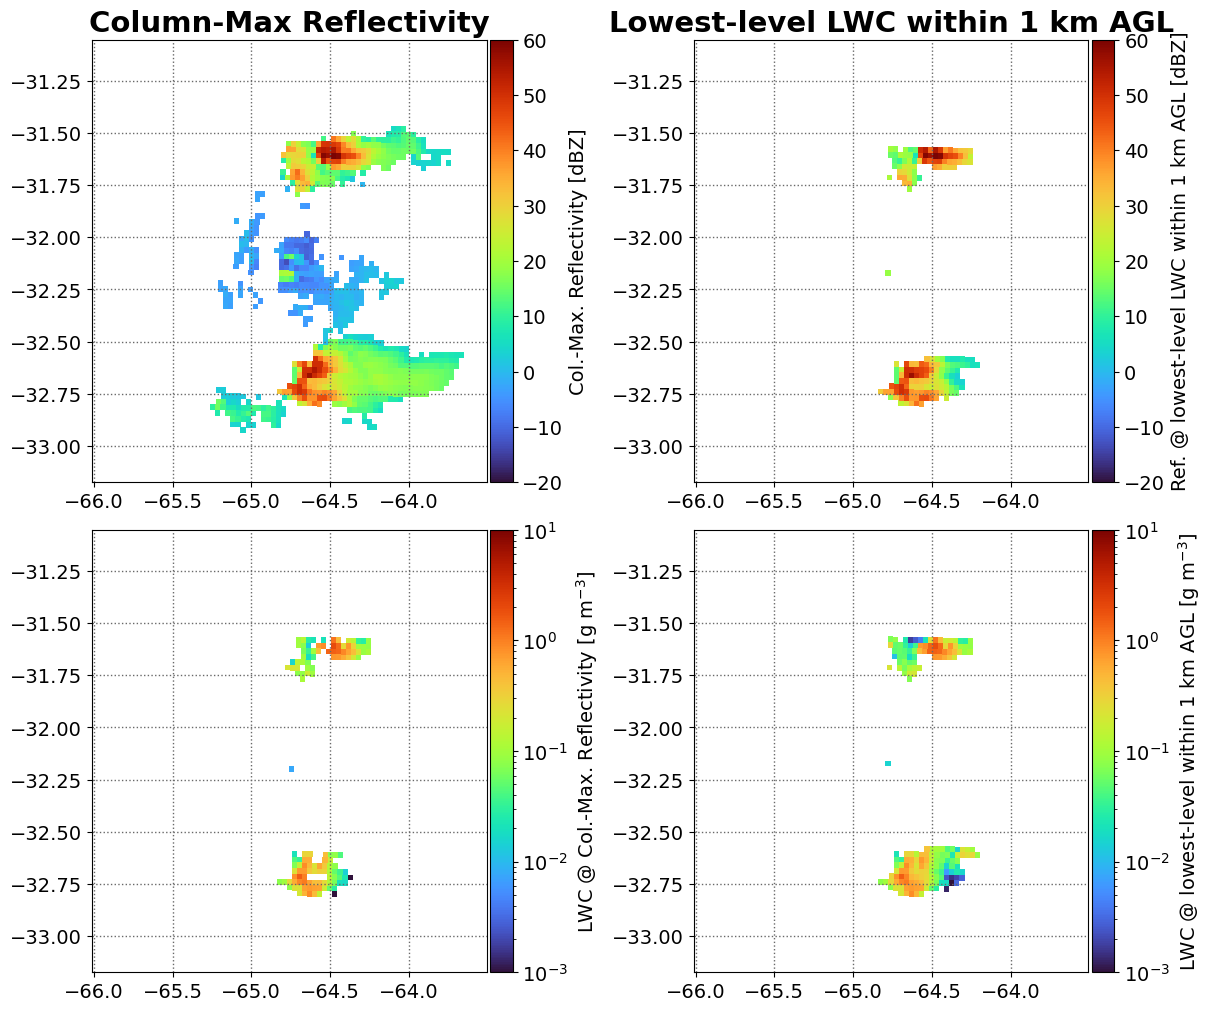

In [132]:
fig = plt.figure(figsize=(12,10),constrained_layout=True)
ax1 = fig.add_subplot(221)
ax2 = fig.add_subplot(222)
ax3 = fig.add_subplot(223)
ax4 = fig.add_subplot(224)
axlist = [ax1,ax2,ax3,ax4]
Fontsize=14
for ax in axlist:
    ax.grid(which='both',lw=1,ls='dotted',c='dimgrey')
    ax.tick_params(labelsize=Fontsize)

tmpplot=ax1.pcolormesh(lon,lat,tmp_csapr_col_max_ref,vmin=-20,vmax=60,cmap='turbo')
cbar = fig.colorbar(tmpplot,pad=0.01)
cbar.ax.set_ylabel('Col.-Max. Reflectivity [dBZ]',fontsize=Fontsize)
cbar.ax.tick_params(labelsize=Fontsize)

tmpplot=ax3.pcolormesh(lon,lat,lwc_at_max_ref,cmap='turbo',norm=mpl.colors.LogNorm(vmin=1.e-3,vmax=1.e1))
cbar = fig.colorbar(tmpplot,pad=0.01)
cbar.ax.set_ylabel('LWC @ Col.-Max. Reflectivity [g m$^{-3}$]',fontsize=Fontsize)
cbar.ax.tick_params(labelsize=Fontsize)


tmpplot=ax2.pcolormesh(lon,lat,tmp_ref_lowest,vmin=-20,vmax=60,cmap='turbo')
cbar = fig.colorbar(tmpplot,pad=0.01)
cbar.ax.set_ylabel('Ref. @ lowest-level LWC within 1 km AGL [dBZ]',fontsize=Fontsize)
cbar.ax.tick_params(labelsize=Fontsize)

tmpplot=ax4.pcolormesh(lon,lat,tmp_lwc_lowest,cmap='turbo',norm=mpl.colors.LogNorm(vmin=1.e-3,vmax=1.e1))
cbar = fig.colorbar(tmpplot,pad=0.01)
cbar.ax.set_ylabel('LWC @ lowest-level within 1 km AGL [g m$^{-3}$]',fontsize=Fontsize)
cbar.ax.tick_params(labelsize=Fontsize)



ax1.set_title('Column-Max Reflectivity',fontsize=Fontsize*1.5,fontweight='bold')
ax2.set_title('Lowest-level LWC within 1 km AGL',fontsize=Fontsize*1.5,fontweight='bold')

plt.show()
plt.close()

In [11]:
for ii in range(len(unique_csapr_match_day)):
    print('Date:',unique_csapr_match_day[ii])
    dumid = np.where(csapr_match_day == unique_csapr_match_day[ii])
    tmp_csapr_files = csapr_match_files[dumid]
    tmp_csapr_datetime = csapr_match_datetime[dumid]
    tmp_csapr_timestamp = csapr_match_timestamp[dumid]
    
    tmp_goes_files = goes_match_files[dumid]
    tmp_goes_datetime = goes_match_datetime[dumid]
    tmp_goes_timestamp = goes_match_timestamp[dumid]
    
    
    print('# of CSAPR files:',len(tmp_csapr_files))
    print('# of GOES files:',len(tmp_goes_files))
    
    goes_ir_tb = []
    goes_ctt = []
    goes_cth = []
    goes_opd = []
    goes_lwp_iwp = []
    goes_particle_size = []
    goes_phase = []
    csapr_col_max_ref = []
    csapr_time = []
    goes_time = []
    
    for jj in range(len(tmp_csapr_files)):
        ds = xr.open_dataset(tmp_csapr_files[jj])
        if jj == 0.:
            lon = ds['XLONG'].values
            lat = ds['XLAT'].values
        csapr_col_max_ref.append(np.nanmax(ds['REFL_10CM'].values,axis=0))
        csapr_time.append(ds['XTIME'].values[0])
        ds.close()
        
        ds = xr.open_dataset(tmp_goes_files[jj])
        goes_ir_tb.append(ds['tb_olr'].values.squeeze())
        goes_ctt.append(ds['cloud_top_temperature'].values.squeeze())
        goes_cth.append(ds['cloud_top_height'].values.squeeze())
        goes_opd.append(ds['cloud_visible_optical_depth'].values.squeeze())
        goes_lwp_iwp.append(ds['cloud_lwp_iwp'].values.squeeze())
        goes_particle_size.append(ds['cloud_particle_size'].values.squeeze())
        goes_phase.append(ds['cloud_phase'].values.squeeze())
        goes_time.append(ds['time'].values[0])
        ds.close()
        
    goes_ir_tb = np.asarray(goes_ir_tb)-273.15
    goes_ctt = np.asarray(goes_ctt)-273.15
    goes_cth = np.asarray(goes_cth)
    goes_opd = np.asarray(goes_opd)
    goes_lwp_iwp = np.asarray(goes_lwp_iwp)
    goes_phase = np.asarray(goes_phase)
    goes_particle_size = np.asarray(goes_particle_size)
    goes_time = np.asarray(goes_time)
    csapr_col_max_ref = np.asarray(csapr_col_max_ref)
    csapr_time = np.asarray(csapr_time)
    csapr_epoch = np.asarray([int(to_datetime(csapr_time[dd]).timestamp()) for dd in range(len(csapr_time))])
    goes_epoch = np.asarray([int(to_datetime(goes_time[dd]).timestamp()) for dd in range(len(goes_time))])
    
    
    #==================================================
    # Create Xarray dataset and write to NetCDF file
    #==================================================
    

    # Make dictionary with output variables
    out_dict = {'col_max_ref':csapr_col_max_ref,\
                'ir_tb':goes_ir_tb,\
                'ctt':goes_ctt,\
                'cth':goes_cth,\
                'opd':goes_opd,\
                'lwp_iwp':goes_lwp_iwp,\
                'particle_size':goes_particle_size,\
                'phase':goes_phase,\
                'goes_time':goes_epoch}

    # Define variable attributes
    out_dict_attrs = {
                'col_max_ref': {
                    'long_name': 'Column-Maximum Radar Reflectivity',
                    'units': 'dBZ',
                },
                'ir_tb':{
                    'long_name': 'Infrared Brightness Temperature',
                    'units':'deg C'
                },
                'ctt':{
                    'long_name': 'Cloud-top Temperature',
                    'units':'deg C'
                },
                'cth':{
                    'long_name': 'Cloud-top Height',
                    'units':'km'
                },
                'opd':{
                    'long_name': 'Visible Optical Depth',
                    'units':'unitless',
                },
                'particle_size':{
                    'long_name': 'Effective Particle Radius or Diameter',
                    'units':'um',
                    'description_1':'If cloud_phase = water, this parameter is radius',
                    'description_2':'If cloud_phase = ice, this parameter is diameter',
                },
                'lwp_iwp':{
                    'long_name': 'Liquid or ice water path',
                    'units':'g/m^2',
                    'description_1':'If cloud_phase = water, this parameter is radius',
                    'description_2':'If cloud_phase = ice, this parameter is diameter',
                },
                'phase':{
                    'long_name': 'Cloud phase',
                    'units':'0=clear with snow/ice, 1=water, 2=ice, 3=no retrieval, 4=clear, 5=bad retrieval, 6=weak water, 7=weak ice',
                },
                'goes_time':{
                    'long_name': 'Time of GOES retrieval',
                    'units':'Epoch',
                    'description':'Since time grid corresponds to CSAPR times, this holds the GOES retrieval time that is require to be within 1 minutes of a given CSAPR time'
                }
    }   

    # Output parameters
    output_date = str(unique_csapr_match_day[ii].year)+str(unique_csapr_match_day[ii].month).zfill(2)+str(unique_csapr_match_day[ii].day).zfill(2)
    output_path = '/pscratch/sd/m/mckenna/cacti/matched_csapr_goes/'
    output_filename = f'{output_path}CSAPR_GOES_matched_times_3km_{output_date}.nc'


    # Define dimensions
    time_dimname = 'time'
    lon_dimname = 'west_east'
    lat_dimname = 'south_north'

    var_dict = {}
    # Define output variable dictionary
    for key, value in out_dict.items():
        if np.ndim(value) == 1:
            var_dict[key] = ([time_dimname],value,out_dict_attrs[key])
        if np.ndim(value) == 3.:
            var_dict[key] = ([time_dimname,lat_dimname,lon_dimname],value,out_dict_attrs[key])

    # Define coordinate attributes
    coord_attr_dict = {'time':{'long_name':'CSAPR Epoch time','units':'Epoch'},
                       'lon':{'long_name':'Longitude','units':'degrees'},
                       'lat':{'long_name':'Latitude','units':'degrees'},
                      }

    # Define coordinates
    coord_dict = {
            'time': ([time_dimname],csapr_epoch,coord_attr_dict['time']),
            'lon': ([lat_dimname,lon_dimname],lon,coord_attr_dict['lon']),
            'lat': ([lat_dimname,lon_dimname],lat,coord_attr_dict['lat']),
            }

    # Define global attributes
    gattr_dict = {
        'title':  'Matched-time GOES & CSAPR datasets coarse-grained to 3 km for CACTI campaign (10-15-2018 - 03/03/2019)', \
        'Institution': 'Pacific Northwest National Laboratoy', \
        'Contact': 'McKenna Stanford, mckenna.stnaford@pnnl.gov', \
        'Created_on':  time.ctime(time.time()), \
        'source_csapr_path': csapr_path, \
        'source_goes_path': goes_path, \
        'Date': unique_csapr_match_day[ii].strftime('%Y%m%d'), \
    }

    # Define xarray dataset
    dsout = xr.Dataset(var_dict, coords=coord_dict, attrs=gattr_dict)

    # Delete file if it already exists
    if os.path.isfile(output_filename):
        os.remove(output_filename)

    # Set encoding/compression for all variables
    comp = dict(zlib=True)
    encoding = {var: comp for var in dsout.data_vars}

    # Write to netcdf file
    dsout.to_netcdf(path=output_filename, mode="w",
                    format="NETCDF4", unlimited_dims=time_dimname, encoding=encoding)
    
    print('')
    #print(aaaaa)

Date: 2018-10-15 00:00:00+00:00
# of CSAPR files: 96
# of GOES files: 96

Date: 2018-10-16 00:00:00+00:00
# of CSAPR files: 96
# of GOES files: 96

Date: 2018-10-17 00:00:00+00:00
# of CSAPR files: 96
# of GOES files: 96

Date: 2018-10-18 00:00:00+00:00
# of CSAPR files: 96
# of GOES files: 96

Date: 2018-10-19 00:00:00+00:00
# of CSAPR files: 96
# of GOES files: 96

Date: 2018-10-20 00:00:00+00:00
# of CSAPR files: 96
# of GOES files: 96

Date: 2018-10-21 00:00:00+00:00
# of CSAPR files: 96
# of GOES files: 96

Date: 2018-10-22 00:00:00+00:00
# of CSAPR files: 96
# of GOES files: 96

Date: 2018-10-23 00:00:00+00:00
# of CSAPR files: 96
# of GOES files: 96

Date: 2018-10-24 00:00:00+00:00
# of CSAPR files: 79
# of GOES files: 79

Date: 2018-10-25 00:00:00+00:00
# of CSAPR files: 95
# of GOES files: 95

Date: 2018-10-26 00:00:00+00:00
# of CSAPR files: 96
# of GOES files: 96

Date: 2018-10-27 00:00:00+00:00
# of CSAPR files: 96
# of GOES files: 96

Date: 2018-10-28 00:00:00+00:00
# of C

In [167]:
#csapr_epoch = np.asarray([int(to_datetime(csapr_time[dd]).timestamp()) for dd in range(len(csapr_time))])
#goes_epoch = np.asarray([int(to_datetime(goes_time[dd]).timestamp()) for dd in range(len(goes_time))])
    

## Define LASSO Dates and Time Ranges to subset GOES & CSAPR files

In [19]:
lasso_start_time_1 = datetime.datetime(2018,11,29,0,0,0,tzinfo=utc)
lasso_start_time_2 = datetime.datetime(2018,12,4,0,0,0,tzinfo=utc)
lasso_start_time_3 = datetime.datetime(2018,12,5,0,0,0,tzinfo=utc)
lasso_start_time_4 = datetime.datetime(2018,12,19,0,0,0,tzinfo=utc)
lasso_start_time_5 = datetime.datetime(2019,1,22,0,0,0,tzinfo=utc)
lasso_start_time_6 = datetime.datetime(2019,1,23,0,0,0,tzinfo=utc)
lasso_start_time_7 = datetime.datetime(2019,1,25,0,0,0,tzinfo=utc)
lasso_start_time_8 = datetime.datetime(2019,1,29,0,0,0,tzinfo=utc)
lasso_start_time_9 = datetime.datetime(2019,2,8,0,0,0,tzinfo=utc)

lasso_start_datetime = [lasso_start_time_1,lasso_start_time_2,lasso_start_time_3,\
                     lasso_start_time_4,lasso_start_time_5,lasso_start_time_6,\
                     lasso_start_time_7,lasso_start_time_8,lasso_start_time_9]

lasso_end_datetime = []
num_lasso_dates = len(lasso_start_datetime)
for ii in range(num_lasso_dates):
    lasso_end_datetime.append(lasso_start_datetime[ii] + datetime.timedelta(days=1))
    
lasso_start_timestamp = []
lasso_end_timestamp = []
for ii in range(num_lasso_dates):
    lasso_start_timestamp.append(int(lasso_start_datetime[ii].timestamp()))
    lasso_end_timestamp.append(int(lasso_end_datetime[ii].timestamp()))
    
lasso_start_timestamp = np.array(lasso_start_timestamp)
lasso_end_timestamp = np.array(lasso_end_timestamp)

In [23]:
## Grab CSAPR & GOES files that fall within LASSO dates

csapr_lasso_files = []
csapr_lasso_datetime = []
csapr_lasso_timestamp = []

goes_lasso_files = []
goes_lasso_datetime = []
goes_lasso_timestamp = []

for ii in range(num_lasso_dates):
    dumid = np.where( (csapr_timestamp >= lasso_start_timestamp[ii]) & (csapr_timestamp <= lasso_end_timestamp[ii]) )[0]
    csapr_lasso_files.append(np.array(csapr_files)[dumid])
    csapr_lasso_datetime.append(np.array(csapr_datetime)[dumid])
    csapr_lasso_timestamp.append(csapr_timestamp[dumid])
    
    dumid = np.where( (goes_timestamp >= lasso_start_timestamp[ii]) & (goes_timestamp <= lasso_end_timestamp[ii]) )[0]
    goes_lasso_files.append(np.array(goes_files)[dumid])
    goes_lasso_datetime.append(np.array(goes_datetime)[dumid])
    goes_lasso_timestamp.append(goes_timestamp[dumid])

In [24]:
for ii in range(num_lasso_dates):
    print('# of CSAPR files between {} and {}:'.format(lasso_start_datetime[ii],lasso_end_datetime[ii]),len(csapr_lasso_files[ii]))
print('')
for ii in range(num_lasso_dates):
    print('# of GOES files between {} and {}:'.format(lasso_start_datetime[ii],lasso_end_datetime[ii]),len(goes_lasso_files[ii]))

# of CSAPR files between 2018-11-29 00:00:00+00:00 and 2018-11-30 00:00:00+00:00: 96
# of CSAPR files between 2018-12-04 00:00:00+00:00 and 2018-12-05 00:00:00+00:00: 96
# of CSAPR files between 2018-12-05 00:00:00+00:00 and 2018-12-06 00:00:00+00:00: 96
# of CSAPR files between 2018-12-19 00:00:00+00:00 and 2018-12-20 00:00:00+00:00: 96
# of CSAPR files between 2019-01-22 00:00:00+00:00 and 2019-01-23 00:00:00+00:00: 96
# of CSAPR files between 2019-01-23 00:00:00+00:00 and 2019-01-24 00:00:00+00:00: 96
# of CSAPR files between 2019-01-25 00:00:00+00:00 and 2019-01-26 00:00:00+00:00: 71
# of CSAPR files between 2019-01-29 00:00:00+00:00 and 2019-01-30 00:00:00+00:00: 96
# of CSAPR files between 2019-02-08 00:00:00+00:00 and 2019-02-09 00:00:00+00:00: 82

# of GOES files between 2018-11-29 00:00:00+00:00 and 2018-11-30 00:00:00+00:00: 96
# of GOES files between 2018-12-04 00:00:00+00:00 and 2018-12-05 00:00:00+00:00: 96
# of GOES files between 2018-12-05 00:00:00+00:00 and 2018-12-06 0

# Make dictionary that merges CSAPR & GOES according to LASSO dates

In [126]:
merge_dict = {}
for ii in range(num_lasso_dates):
    date_str = str(lasso_start_datetime[ii].year)+str(lasso_start_datetime[ii].month).zfill(2)+str(lasso_start_datetime[ii].day).zfill(2)
    merge_dict[date_str] = {}
    tmp_csapr_lasso_files = csapr_lasso_files[ii]
    
    csapr_time = []
    csapr_col_max_ref = []
    for jj in range(len(tmp_csapr_lasso_files)):
        ds = xr.open_dataset(tmp_csapr_lasso_files[jj])
        xtime = to_datetime(ds['XTIME'].values[0])
        if jj == 0.:
            csapr_lat = ds['XLAT'].values
            csapr_lon = ds['XLONG'].values
        tmp_ref = ds['REFL_10CM'].values
        col_max_ref = np.nanmax(tmp_ref,axis=0)
        csapr_col_max_ref.append(col_max_ref)
        csapr_time.append(xtime)
    csapr_time = np.asarray(csapr_time)
    csapr_col_max_ref = np.asarray(csapr_col_max_ref)
    
    merge_dict[date_str]['csapr_col_max_ref'] = csapr_col_max_ref
    merge_dict[date_str]['csapr_time'] = csapr_time
    merge_dict[date_str]['csapr_lon'] = csapr_lon
    merge_dict[date_str]['csapr_lat'] = csapr_lat

In [127]:
for ii in range(num_lasso_dates):
    date_str = str(lasso_start_datetime[ii].year)+str(lasso_start_datetime[ii].month).zfill(2)+str(lasso_start_datetime[ii].day).zfill(2)
    tmp_goes_lasso_files = goes_lasso_files[ii]
    
    goes_time = []
    goes_tb_olr = []
    
    for jj in range(len(tmp_goes_lasso_files)):
        ds = xr.open_dataset(tmp_goes_lasso_files[jj])
        xtime = to_datetime(ds['time'].values[0])
        if jj == 0.:
            goes_lat = ds['lat'].values
            goes_lon = ds['lon'].values
        tmp_tb_olr = ds['tb_olr'].values.squeeze()
        goes_tb_olr.append(tmp_tb_olr)
        goes_time.append(xtime)
    goes_time = np.asarray(goes_time)
    goes_tb_olr = np.asarray(goes_tb_olr)
    
    merge_dict[date_str]['goes_tb_olr'] = goes_tb_olr
    merge_dict[date_str]['goes_time'] = goes_time
    merge_dict[date_str]['goes_lon'] = goes_lon
    merge_dict[date_str]['goes_lat'] = goes_lat

In [96]:
if True:
    for key in merge_dict.keys():
        print(key)
        for key2,val2 in merge_dict[key].items():
            print('  ',key2,np.shape(val2),np.nanmax(val2),np.nanmin(val2))

20181129
   csapr_col_max_ref (96, 77, 77) 60.847494661981685 -35.0
   csapr_time (96,) 2018-11-29 23:45:03+00:00 2018-11-29 00:00:03+00:00
   csapr_lon (77, 77) -63.521606 -65.995544
   csapr_lat (77, 77) -31.065887 -33.160767
   goes_tb_olr (96, 77, 77) 311.28738 215.56415
   goes_time (96,) 2018-11-29 23:45:35+00:00 2018-11-29 00:00:35+00:00
   goes_lon (77, 77) -63.521606 -65.995544
   goes_lat (77, 77) -31.065887 -33.160767
20181204
   csapr_col_max_ref (96, 77, 77) 59.59230263972031 -35.0
   csapr_time (96,) 2018-12-04 23:45:04+00:00 2018-12-04 00:00:03+00:00
   csapr_lon (77, 77) -63.521606 -65.995544
   csapr_lat (77, 77) -31.065887 -33.160767
   goes_tb_olr (96, 77, 77) 317.9404 213.49141
   goes_time (96,) 2018-12-04 23:45:33+00:00 2018-12-04 00:00:35+00:00
   goes_lon (77, 77) -63.521606 -65.995544
   goes_lat (77, 77) -31.065887 -33.160767
20181205
   csapr_col_max_ref (96, 77, 77) 61.452224345273564 -35.0
   csapr_time (96,) 2018-12-05 23:45:03+00:00 2018-12-05 00:00:03+00

# Go through LASSO dates and find where GOES times are within 1 minute of CSAPR times

In [128]:
new_merge_dict = {}

for ii in range(num_lasso_dates):
    date_str = str(lasso_start_datetime[ii].year)+str(lasso_start_datetime[ii].month).zfill(2)+str(lasso_start_datetime[ii].day).zfill(2)
    new_merge_dict[date_str] = {}
    new_merge_dict[date_str]['lon'] = csapr_lon
    new_merge_dict[date_str]['lat'] = csapr_lat
    new_merge_dict[date_str]['csapr_time'] = []
    new_merge_dict[date_str]['goes_time'] = []
    new_merge_dict[date_str]['csapr_col_max_ref'] = []
    new_merge_dict[date_str]['goes_tb_olr'] = []
    new_merge_dict[date_str]['time_diff'] = []
    
    tmp_goes_lasso_datetime = goes_lasso_datetime[ii]
    tmp_goes_lasso_timestamp = goes_lasso_timestamp[ii]
    tmp_csapr_lasso_datetime = csapr_lasso_datetime[ii]
    tmp_csapr_lasso_timestamp = csapr_lasso_timestamp[ii]

    for jj in range(len(tmp_csapr_lasso_datetime)):
        diff_times = tmp_goes_lasso_timestamp - tmp_csapr_lasso_timestamp[jj]
        diff_times = np.abs(diff_times)
        if np.min(diff_times) < 60.:
            new_merge_dict[date_str]['csapr_time'].append(merge_dict[date_str]['csapr_time'][jj])
            new_merge_dict[date_str]['csapr_col_max_ref'].append(merge_dict[date_str]['csapr_col_max_ref'][jj,:,:])
            dumid = np.argmin(diff_times)
            new_merge_dict[date_str]['goes_time'].append(merge_dict[date_str]['goes_time'][dumid])
            new_merge_dict[date_str]['goes_tb_olr'].append(merge_dict[date_str]['goes_tb_olr'][dumid])
            new_merge_dict[date_str]['time_diff'].append(np.min(diff_times))
    new_merge_dict[date_str]['goes_time'] = np.asarray(new_merge_dict[date_str]['goes_time'])
    new_merge_dict[date_str]['goes_tb_olr'] = np.asarray(new_merge_dict[date_str]['goes_tb_olr'])
    new_merge_dict[date_str]['csapr_time'] = np.asarray(new_merge_dict[date_str]['csapr_time'])
    new_merge_dict[date_str]['csapr_col_max_ref'] = np.asarray(new_merge_dict[date_str]['csapr_col_max_ref'])
    new_merge_dict[date_str]['time_diff'] = np.asarray(new_merge_dict[date_str]['time_diff'])
    
merge_dict = new_merge_dict
del new_merge_dict

In [105]:
if False:
    for key in new_merge_dict.keys():
        #print(key)
        #print(key,np.min(new_merge_dict[key]['time_diff']))
        print(key,new_merge_dict[key]['time_diff'])
        #for key2,val2 in new_merge_dict[key].items():
        #    print('  ',key2,np.shape(val2))

# Plot histograms of CSAPR col.-max. reflectivity, GOES IR Tb, and joint histograms for each lasso date

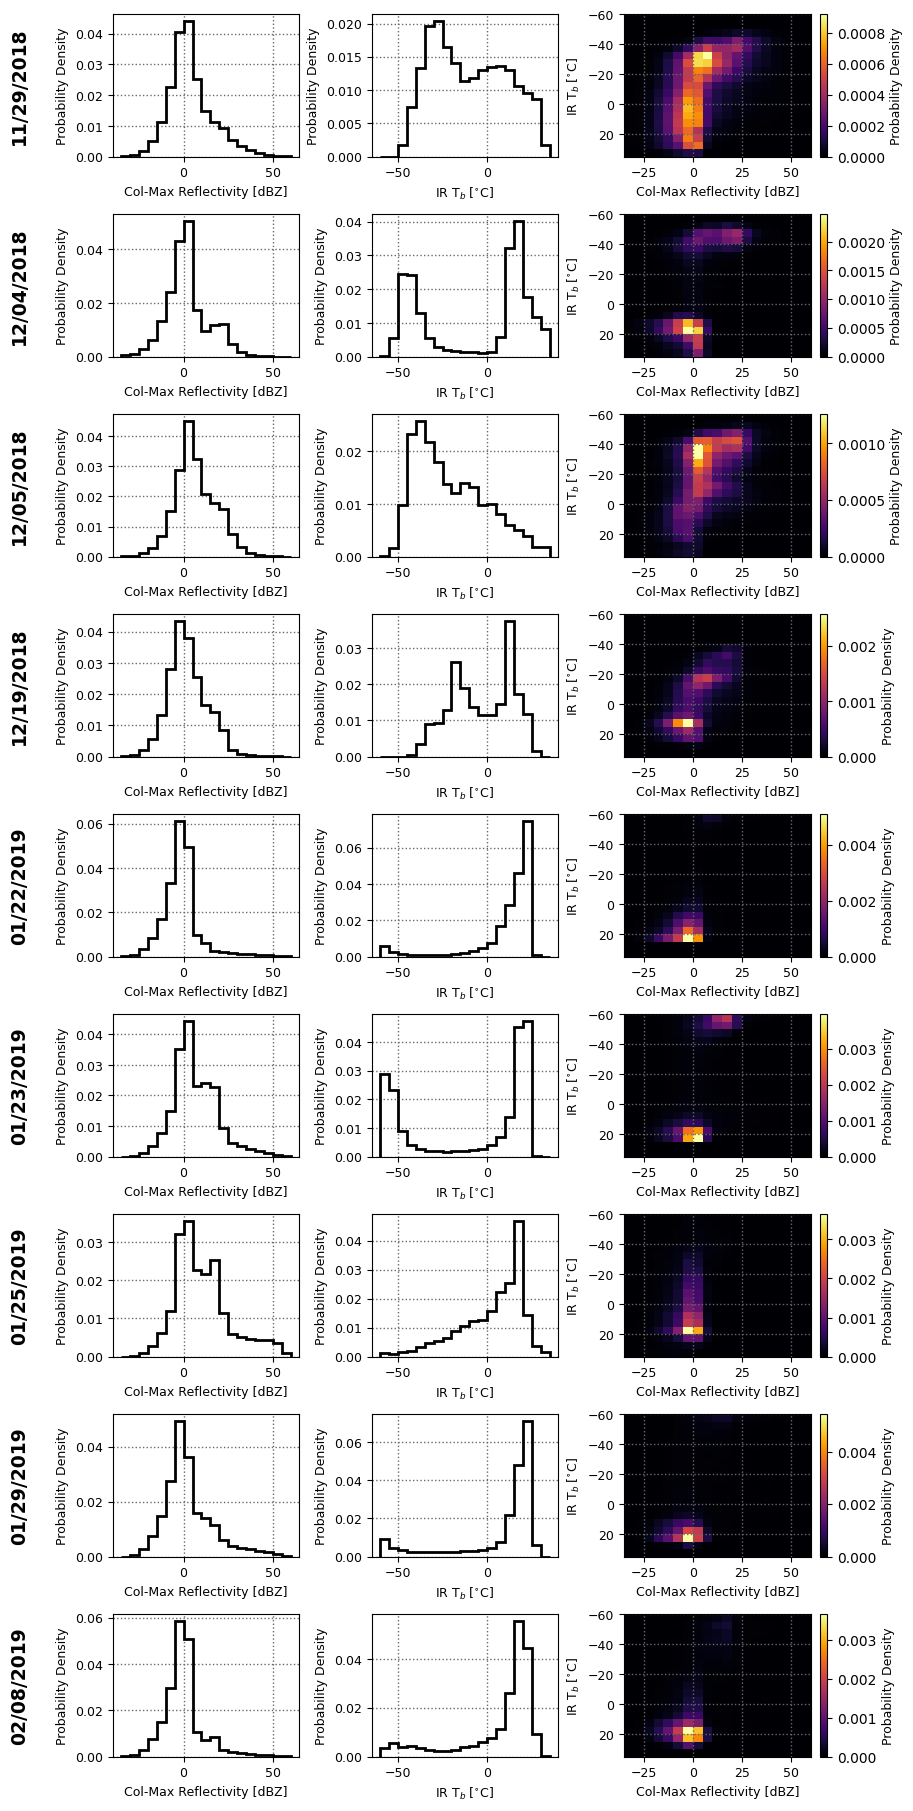

In [168]:
nrows=9
ncols=3
fig,axes = plt.subplots(nrows=nrows,ncols=ncols,figsize=(9,18),constrained_layout=True)
axes_flat = np.ndarray.flatten(axes)
Fontsize=9
for ax in axes_flat:
    ax.tick_params(labelsize=Fontsize)
    ax.grid(which='both',lw=1,c='dimgrey',ls='dotted')
    
for ii in range(nrows):
    axes[ii,0].set_ylabel('Probability Density',fontsize=Fontsize)
    axes[ii,1].set_ylabel('Probability Density',fontsize=Fontsize)
    axes[ii,2].set_ylabel('IR T$_{b}$ [$^{\\circ}$C]',fontsize=Fontsize)
    axes[ii,0].set_xlabel('Col-Max Reflectivity [dBZ]',fontsize=Fontsize)
    axes[ii,1].set_xlabel('IR T$_{b}$ [$^{\\circ}$C]',fontsize=Fontsize)
    axes[ii,2].set_xlabel('Col-Max Reflectivity [dBZ]',fontsize=Fontsize)
    
dumi=0
for key in merge_dict.keys():
    tmp_ref = np.ndarray.flatten(merge_dict[key]['csapr_col_max_ref'].copy())
    tmp_ir_tb = np.ndarray.flatten(merge_dict[key]['goes_tb_olr'].copy())-273.15
    dumid = np.where(~np.isnan(tmp_ref))
    tmp_ref = tmp_ref[dumid]
    tmp_ir_tb = tmp_ir_tb[dumid]
    
    ref_bins = np.arange(-35,65,5)
    ir_tb_bins = np.arange(-60,40,5)
    axes[dumi,0].hist(tmp_ref,bins=ref_bins,histtype='step',color='k',density=True,lw=2)
    axes[dumi,1].hist(tmp_ir_tb,bins=ir_tb_bins,histtype='step',color='k',density=True,lw=2)
    dumplot=axes[dumi,2].hist2d(tmp_ref,tmp_ir_tb,bins=[ref_bins,ir_tb_bins],cmap='inferno',density=True)
    axes[dumi,2].invert_yaxis()
    cbar = fig.colorbar(dumplot[3],pad=0.05)
    cbar.ax.set_ylabel('Probability Density',fontsize=Fontsize)
    
    axes[dumi,0].text(-0.5,0.5,key[4:6]+'/'+key[6:8]+'/'+key[0:4],va='center',ha='center',rotation=90,transform=axes[dumi,0].transAxes,fontsize=Fontsize*1.5,fontweight='bold')
    
    #print(aaaa)
    dumi+=1
    if dumi > 8:
        break

plt.show()
plt.close()

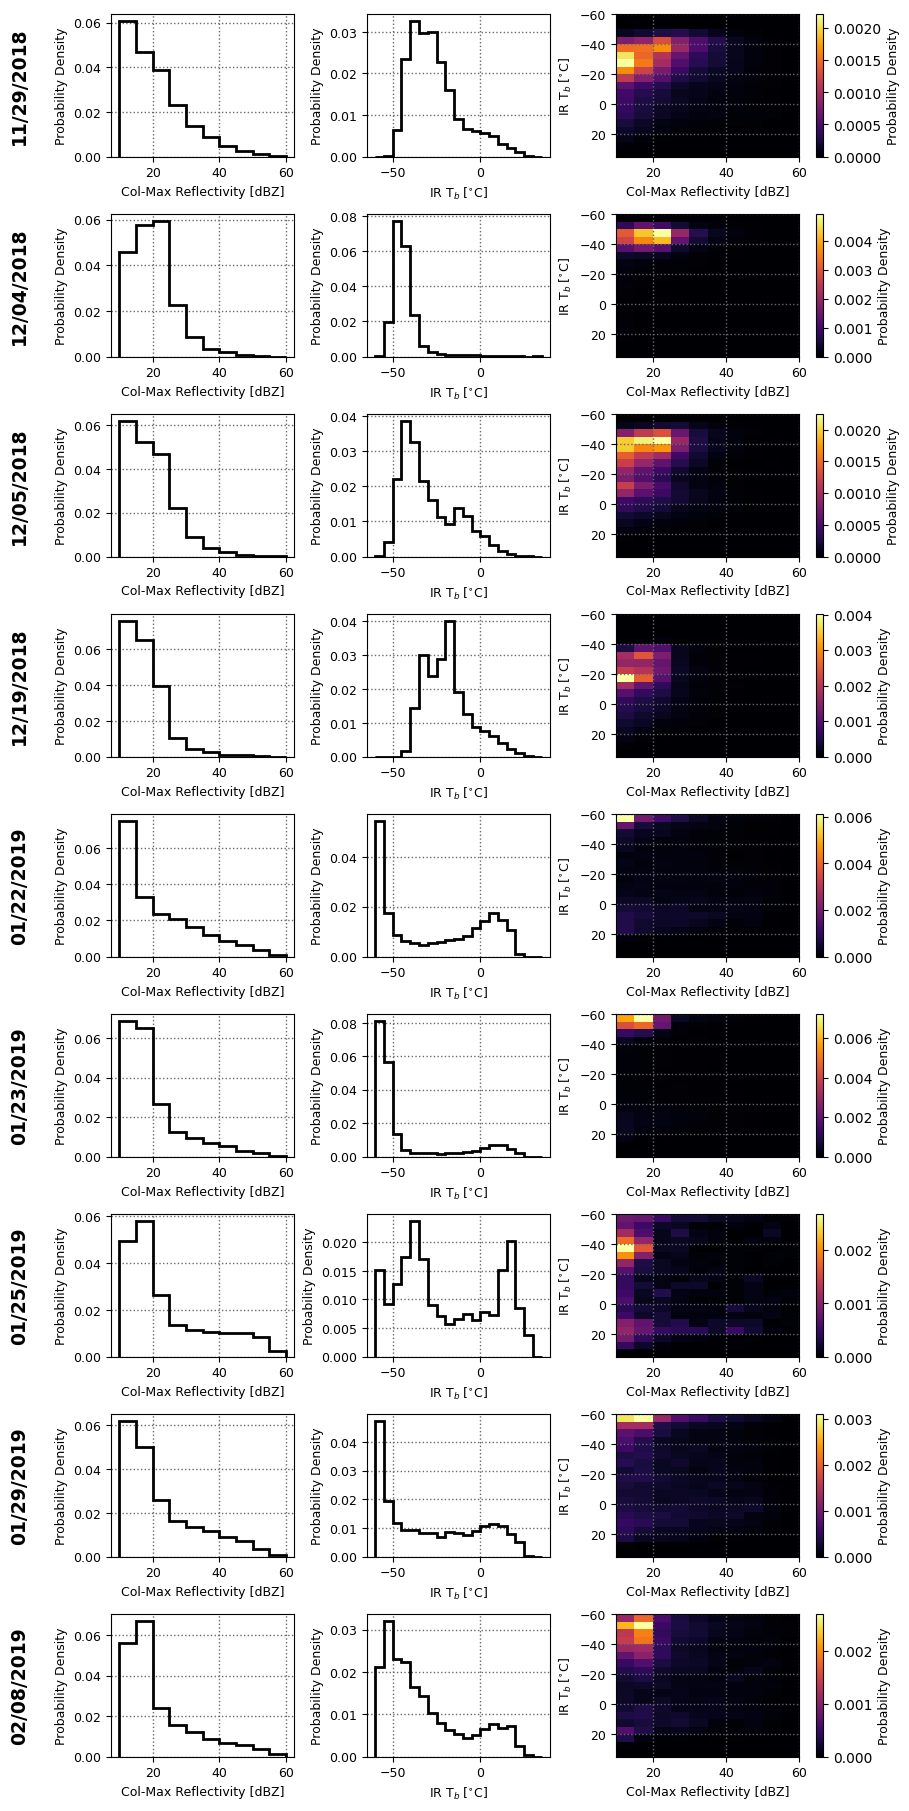

In [169]:
nrows=9
ncols=3
fig,axes = plt.subplots(nrows=nrows,ncols=ncols,figsize=(9,18),constrained_layout=True)
axes_flat = np.ndarray.flatten(axes)
Fontsize=9
for ax in axes_flat:
    ax.tick_params(labelsize=Fontsize)
    ax.grid(which='both',lw=1,c='dimgrey',ls='dotted')
    
for ii in range(nrows):
    axes[ii,0].set_ylabel('Probability Density',fontsize=Fontsize)
    axes[ii,1].set_ylabel('Probability Density',fontsize=Fontsize)
    axes[ii,2].set_ylabel('IR T$_{b}$ [$^{\\circ}$C]',fontsize=Fontsize)
    axes[ii,0].set_xlabel('Col-Max Reflectivity [dBZ]',fontsize=Fontsize)
    axes[ii,1].set_xlabel('IR T$_{b}$ [$^{\\circ}$C]',fontsize=Fontsize)
    axes[ii,2].set_xlabel('Col-Max Reflectivity [dBZ]',fontsize=Fontsize)
    
dumi=0
for key in merge_dict.keys():
    tmp_ref = np.ndarray.flatten(merge_dict[key]['csapr_col_max_ref'].copy())
    tmp_ir_tb = np.ndarray.flatten(merge_dict[key]['goes_tb_olr'].copy())-273.15
    dumid = np.where(tmp_ref > 10.)
    tmp_ref = tmp_ref[dumid]
    tmp_ir_tb = tmp_ir_tb[dumid]
    
    ref_bins = np.arange(10,65,5)
    ir_tb_bins = np.arange(-60,40,5)
    axes[dumi,0].hist(tmp_ref,bins=ref_bins,histtype='step',color='k',density=True,lw=2)
    axes[dumi,1].hist(tmp_ir_tb,bins=ir_tb_bins,histtype='step',color='k',density=True,lw=2)
    dumplot=axes[dumi,2].hist2d(tmp_ref,tmp_ir_tb,bins=[ref_bins,ir_tb_bins],cmap='inferno',density=True)
    axes[dumi,2].invert_yaxis()
    cbar = fig.colorbar(dumplot[3],pad=0.05)
    cbar.ax.set_ylabel('Probability Density',fontsize=Fontsize)
    
    axes[dumi,0].text(-0.5,0.5,key[4:6]+'/'+key[6:8]+'/'+key[0:4],va='center',ha='center',rotation=90,transform=axes[dumi,0].transAxes,fontsize=Fontsize*1.5,fontweight='bold')
    
    #print(aaaa)
    dumi+=1
    if dumi > 8:
        break

plt.show()
plt.close()

In [171]:
all_dates_ref = []
all_dates_ir_tb = []
for key in merge_dict.keys():
    tmp_ref = np.ndarray.flatten(merge_dict[key]['csapr_col_max_ref'].copy())
    tmp_ir_tb = np.ndarray.flatten(merge_dict[key]['goes_tb_olr'].copy())-273.15
    dumid = np.where(tmp_ref > 10.)
    tmp_ref = tmp_ref[dumid]
    tmp_ir_tb = tmp_ir_tb[dumid]
    all_dates_ref.append(tmp_ref)
    all_dates_ir_tb.append(tmp_ir_tb)
    
all_dates_ref = np.concatenate(all_dates_ref)
all_dates_ir_tb = np.concatenate(all_dates_ir_tb)

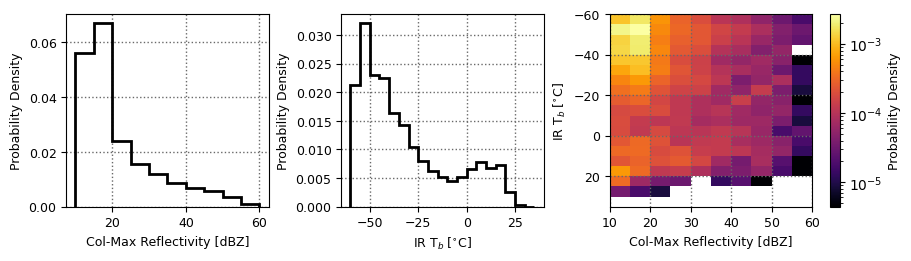

In [179]:
nrows=1
ncols=3
fig,axes = plt.subplots(nrows=nrows,ncols=ncols,figsize=(9,2.5),constrained_layout=True)
#axes_flat = np.ndarray.flatten(axes)
Fontsize=9
for ax in axes:
    ax.tick_params(labelsize=Fontsize)
    ax.grid(which='both',lw=1,c='dimgrey',ls='dotted')
    
axes[0].set_ylabel('Probability Density',fontsize=Fontsize)
axes[1].set_ylabel('Probability Density',fontsize=Fontsize)
axes[2].set_ylabel('IR T$_{b}$ [$^{\\circ}$C]',fontsize=Fontsize)
axes[0].set_xlabel('Col-Max Reflectivity [dBZ]',fontsize=Fontsize)
axes[1].set_xlabel('IR T$_{b}$ [$^{\\circ}$C]',fontsize=Fontsize)
axes[2].set_xlabel('Col-Max Reflectivity [dBZ]',fontsize=Fontsize)
    

ref_bins = np.arange(10,65,5)
ir_tb_bins = np.arange(-60,40,5)
axes[0].hist(tmp_ref,bins=ref_bins,histtype='step',color='k',density=True,lw=2)
axes[1].hist(tmp_ir_tb,bins=ir_tb_bins,histtype='step',color='k',density=True,lw=2)
dumplot=axes[2].hist2d(tmp_ref,tmp_ir_tb,bins=[ref_bins,ir_tb_bins],cmap='inferno',density=True,norm=mpl.colors.LogNorm())
axes[2].invert_yaxis()
cbar = fig.colorbar(dumplot[3],pad=0.05)
cbar.ax.set_ylabel('Probability Density',fontsize=Fontsize)
    
plt.show()
plt.close()